# Dog vs Cat Detection 🐶🐈

This notebook implements a Convolutional Neural Network (CNN) from scratch to classify images of cats and dogs.  
It includes all key steps from data loading and augmentation to model training, evaluation, and visualization.

## Importing libraries

In [1]:
import os
import numpy as np
import requests
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import PIL.ImageOps
from PIL import Image
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler

import warnings
warnings.filterwarnings('ignore')

In [2]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
device

'cuda'

## Data Loading and Preprocessing

We define training and validation datasets using `ImageFolder`,  
and apply suitable transformations including normalization and data augmentation.

- **Train transforms:** Random flips, rotations, etc. for generalization  
- **Test transforms:** Only resizing and normalization  

In [3]:
training_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

training_dataset = datasets.ImageFolder('./dataset/training_set/', transform=training_transform)
test_dataset = datasets.ImageFolder('./dataset/test_set/', transform=test_transform)

training_loader = DataLoader(training_dataset, batch_size=64, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True, drop_last=True)

print(f'Classes: {training_dataset.classes}')
print(f'Train instances: {len(training_dataset)}')
print(f'Val instances: {len(test_dataset)}')

Classes: ['cats', 'dogs']
Train instances: 8005
Val instances: 2023


## Visualize Sample Images

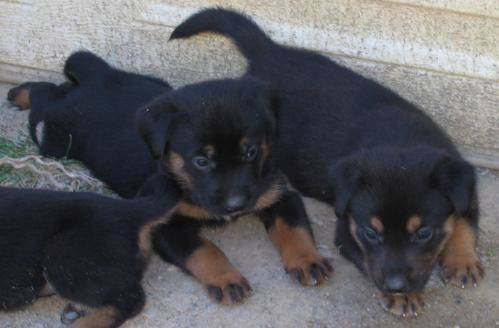

In [4]:
Image.open('./dataset/training_set/dogs/dog.500.jpg')

In [5]:
def im_convert(tensor):
    image = tensor.cpu().clone().detach().numpy()
    image = image.transpose(1, 2, 0)
    image = image * np.array((.5, .5, .5)) + np.array((.5, .5, .5))
    image = image.clip(0, 1)
    return image

## Define the CNN Architecture

Below is our CNN model with three convolutional blocks,  
Batch Normalization, Dropout, and Adaptive Average Pooling for size invariance.

**Architecture Summary:**
- 3 convolutional layers with ReLU + MaxPooling  
- Adaptive average pooling before the dense layers  
- Fully connected layers for binary classification (Cat/Dog)

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc1 = nn.Linear(64, 800) 
        self.fc2 = nn.Linear(800, 400)
        self.fc3 = nn.Linear(400, 2)

        self.bn1 = nn.BatchNorm1d(800)
        self.bn2 = nn.BatchNorm1d(400)

        self.drop = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.drop(x)
        x = self.fc3(x)
        return x
        

In [8]:
model = CNN().to(device)
model

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=64, out_features=800, bias=True)
  (fc2): Linear(in_features=800, out_features=400, bias=True)


## Define Loss Function, Optimizer, and Scheduler

We use:
- **Loss Function:** CrossEntropyLoss  
- **Optimizer:** Adam with L2 weight decay (regularization)  
- **Scheduler:** OneCycleLR for dynamic learning rate adjustment

In [9]:
num_epochs = 25
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01,                
    steps_per_epoch=len(training_loader),
    epochs=num_epochs
)

## Training Loop

This section contains the full training loop:
- Forward pass  
- Loss computation  
- Backpropagation and optimization  
- Validation after each epoch  

We also track and store loss and accuracy for both train and validation sets.

In [10]:
loss_history = []
corrects_history = []
val_loss_history = []
val_corrects_history = []
for epoch in range(num_epochs):
    running_loss = 0.0
    running_corrects = 0.0
    val_running_loss = 0.0
    val_running_corrects = 0.0

    for images, labels in training_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

    else:
        with torch.no_grad():
            for val_images, val_labels in test_loader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)

                val_outputs = model(val_images)
                _, val_preds = torch.max(val_outputs, 1)
                val_loss = criterion(val_outputs, val_labels)
        
                val_running_loss += val_loss.item()
                val_running_corrects += torch.sum(val_preds == val_labels.data)
            
        epoch_loss = running_loss / len(training_loader)
        epoch_acc = running_corrects.float() / len(training_loader.dataset)
        val_epoch_loss = val_running_loss / len(test_loader)
        val_epoch_acc = val_running_corrects.float() / len(test_loader.dataset)
        
        loss_history.append(epoch_loss)
        corrects_history.append(epoch_acc)
        val_loss_history.append(val_epoch_loss)
        val_corrects_history.append(val_epoch_acc)

        print('\nEpoch :', (epoch+1))
        print('Training loss: {:.4f}, acc {:.4f} '.format(epoch_loss, epoch_acc.item()))
        print('Validation loss: {:.4f}, validation acc {:.4f} '.format(val_epoch_loss, val_epoch_acc.item()))


Epoch : 1
Training loss: 0.6887, acc 0.5836 
Validation loss: 0.6625, validation acc 0.6179 

Epoch : 2
Training loss: 0.6455, acc 0.6309 
Validation loss: 0.6526, validation acc 0.6149 

Epoch : 3
Training loss: 0.6557, acc 0.6150 
Validation loss: 0.6382, validation acc 0.6184 

Epoch : 4
Training loss: 0.6462, acc 0.6270 
Validation loss: 0.6541, validation acc 0.6401 

Epoch : 5
Training loss: 0.6601, acc 0.6254 
Validation loss: 0.6137, validation acc 0.6624 

Epoch : 6
Training loss: 0.6350, acc 0.6417 
Validation loss: 0.6108, validation acc 0.6624 

Epoch : 7
Training loss: 0.6174, acc 0.6626 
Validation loss: 0.5960, validation acc 0.6663 

Epoch : 8
Training loss: 0.6019, acc 0.6742 
Validation loss: 0.5921, validation acc 0.6708 

Epoch : 9
Training loss: 0.5950, acc 0.6808 
Validation loss: 0.6204, validation acc 0.6421 

Epoch : 10
Training loss: 0.5819, acc 0.6904 
Validation loss: 0.5715, validation acc 0.6920 

Epoch : 11
Training loss: 0.5751, acc 0.7003 
Validation l

## Model Evaluation and Visualization

After training, we visualize:
- Accuracy and loss curves  
- Sample predictions vs. ground truth  
- Confusion matrix to understand performance per class

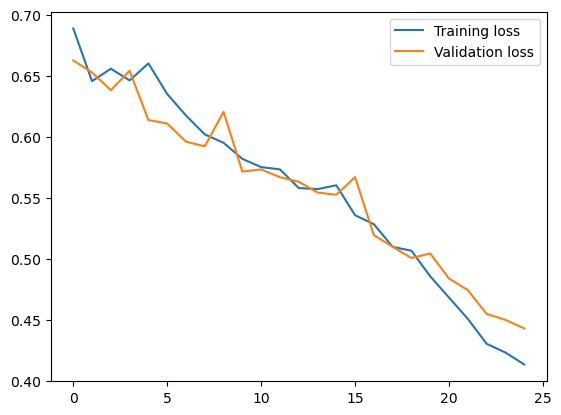

In [11]:
plt.plot(loss_history, label='Training loss')
plt.plot(val_loss_history, label='Validation loss')
plt.legend()
plt.show()

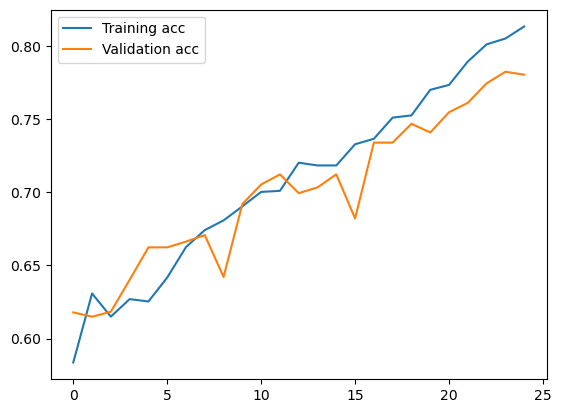

In [12]:
plt.plot([x.cpu().item() for x in corrects_history], label='Training acc')
plt.plot([x.cpu().item() for x in val_corrects_history], label='Validation acc')
plt.legend()
plt.show()

## Save and Load Model

Finally, we save the trained model and show how to reload it later for inference.

In [13]:
# Saving the model
torch.save(model.state_dict(), "mask_detector.pth")

# Loading the model
# model.load_state_dict(torch.load("mask_detector.pth"))
# model.eval()

## Predict on New Images

We define a helper function to predict on single images or online images (from URLs)  
to test the model’s generalization on unseen data.

In [14]:
# Define a function to predict new image
def predict(model, image_path):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    image = test_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)
    return training_dataset.classes[pred.item()]

In [15]:
predict(model, './dataset/training_set/dogs/dog.100.jpg')

'dogs'

In [16]:
def pred_new_img(model, url_path):
    model.eval()
    with torch.no_grad():
        response = requests.get(url_path, stream=True)
        img = Image.open(response.raw).convert('RGB')
        plt.imshow(img)
        
        img = test_transform(img).unsqueeze(0).to(device)
        output = model(img)
        _, pred = torch.max(output, 1)
        print(training_dataset.classes[pred.item()])


dogs


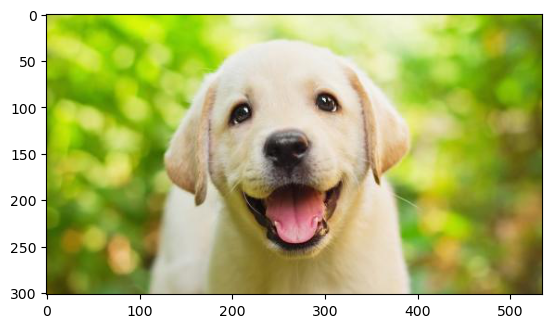

In [22]:
url = 'https://www.tipperarycoco.ie/sites/default/files/styles/localgov_535x302/public/2024-04/Happy%20dog.jpg?itok=uhdQ2Z1G'
pred_new_img(model, url)